In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.lines as mlines
import matplotlib.patches as mpatches



In [2]:
fl_cellcount = pd.read_excel(
    r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\python_FCM_FL.xlsx',
     sheet_name='percellnormtobeads'
)


plt.rcParams['font.family'] = 'Arial'

In [3]:
fl_cellcount.head()

,experiment,Replicate #,Plate #,Strain,Media,Clade,Sensitivity,phase,Date,Day,FL,Dilution,Cell_count,FL per cell_average
0,followup,2,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.088,1,1175200,0.044457
1,followup,3,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.103,1,1508000,0.044262
2,followup,2,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.113,1,1383400,0.038839
3,followup,3,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.064,1,1046500,0.041491
4,followup,2,1_27.4.26,MIT9312,lowP (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.073,1,1349900,0.039009


In [4]:
X = fl_cellcount['FL']
Y = fl_cellcount['Cell_count']

fl_cellcount = fl_cellcount.dropna(subset=['FL', 'Cell_count'])
# Drop rows where Strain is MIT9515
fl_cellcount = fl_cellcount[fl_cellcount['Strain'] != 'MIT9515']



                            OLS Regression Results                            
Dep. Variable:             Cell_count   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     641.7
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           6.75e-77
Time:                        07:57:43   Log-Likelihood:                -5796.5
No. Observations:                 306   AIC:                         1.160e+04
Df Residuals:                     304   BIC:                         1.160e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -3.081e+06   2.93e+06     -1.052      0.2

C:\Users\yaras\AppData\Local\Temp\ipykernel_24500\3267231742.py:41: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yaras\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


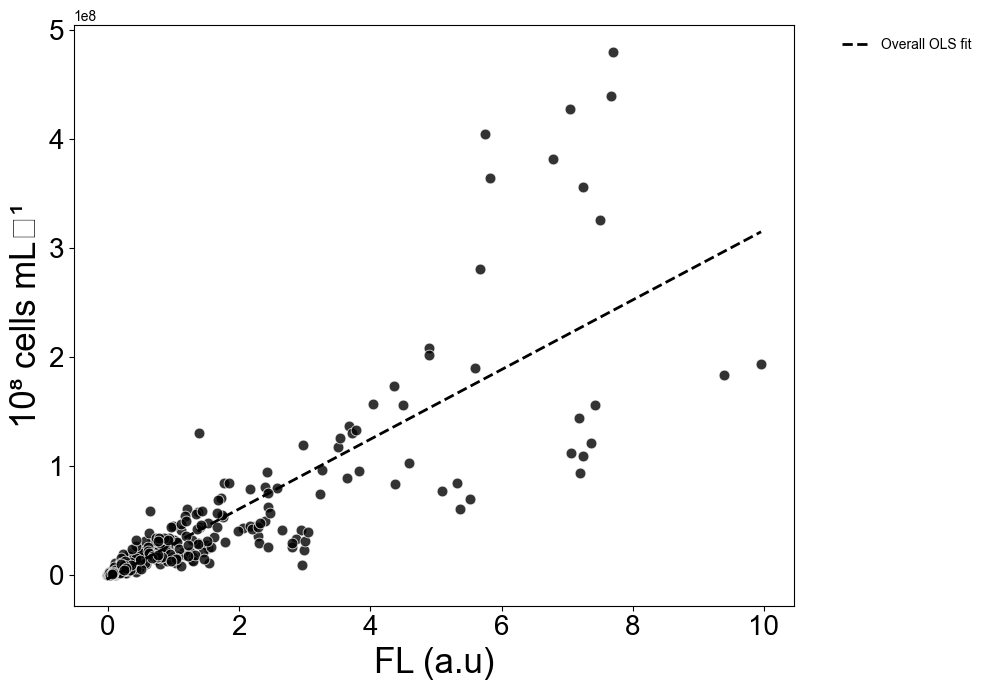

In [5]:
X = fl_cellcount['FL']
Y = fl_cellcount['Cell_count']

# Fit OLS model
X_with_const = sm.add_constant(X)
model = sm.OLS(Y, X_with_const).fit()
print(model.summary())


sort_idx = np.argsort(X)
X_sorted = X.iloc[sort_idx]
Y_pred_sorted = model.predict(X_with_const).iloc[sort_idx]



plt.figure(figsize=(10, 7))

# Scatter plot: Color by Media, Shape (style) by Strain
sns.scatterplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    color='black',
    # style='Strain',

    alpha=0.8,
    s=60
)


plt.plot(X_sorted, Y_pred_sorted, color='black', linestyle='--', linewidth=2, label='Overall OLS fit')

# Labels and title
plt.xlabel('FL (a.u)', fontsize=25)
plt.ylabel('10⁸ cells mL⁻¹', fontsize=25)
plt.tick_params(axis='x', color='black', labelsize=20)
plt.tick_params(axis='y', color='black', labelsize=20)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()

plt.show()

In [6]:
interaction_model = smf.ols(
    formula="Cell_count ~ FL * C(Strain)", data=fl_cellcount
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Cell_count   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     198.1
Date:                Thu, 17 Sep 2026   Prob (F-statistic):          1.07e-119
Time:                        07:57:44   Log-Likelihood:                -5671.9
No. Observations:                 306   AIC:                         1.136e+04
Df Residuals:                     296   BIC:                         1.140e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -1

C:\Users\yaras\AppData\Local\Temp\ipykernel_24500\21366010.py:131: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\yaras\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


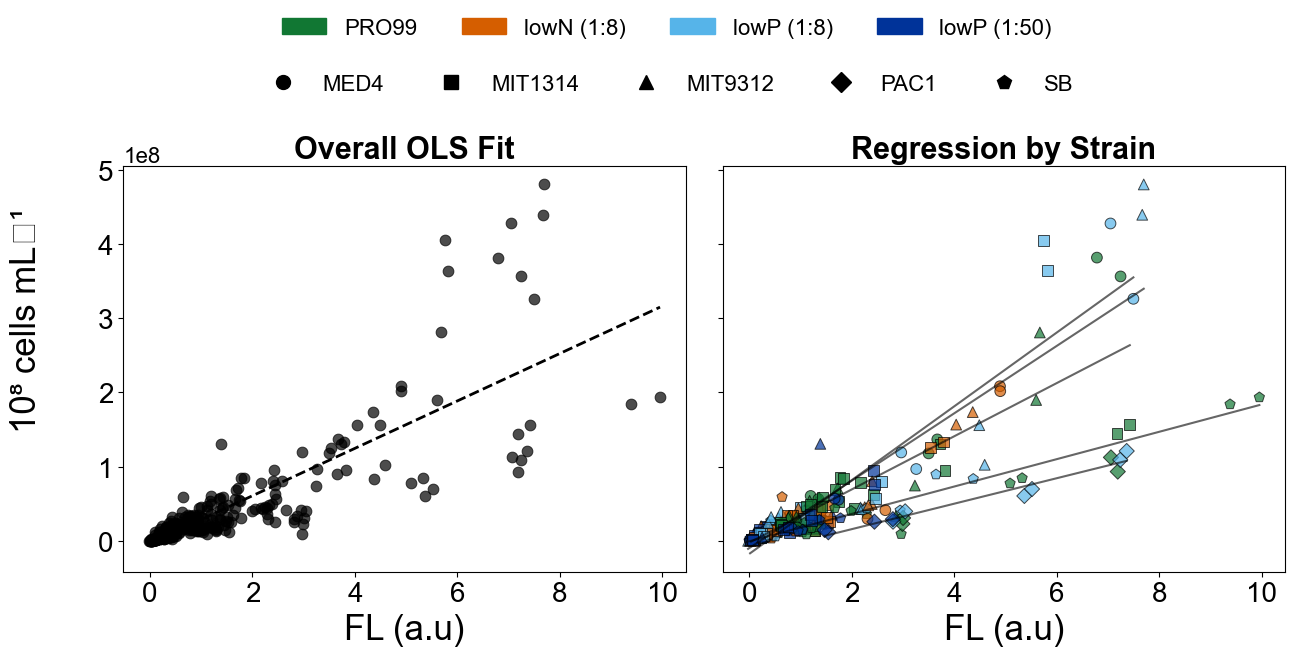

In [7]:
media_palette = {
    'PRO99': '#117733',
    'lowN (1:8)': '#D55E00',
    'lowP (1:8)': '#56B4E9',
    'lowP (1:50)': '#003399'
}


unique_strains = sorted(fl_cellcount['Strain'].unique())
strain_styles = ['o', 's', '^', 'D', 'p', '*', 'X', 'h', 'H', 'd'] 
strain_marker_palette = {
    strain: strain_styles[i % len(strain_styles)] for i, strain in enumerate(unique_strains)
}


plt.rcParams['font.size'] = 16 
label_font = {'fontsize': 25} 

# Panel A

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True) 


fig.supylabel('10⁸ cells mL⁻¹', **label_font, ha='right')


ax = axes[0]


X = fl_cellcount['FL']
Y = fl_cellcount['Cell_count']
X_with_const = sm.add_constant(X)
global_model = sm.OLS(Y, X_with_const).fit()


sns.regplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    scatter=False, 
    ci=None, # Removes the gray shaded confidence band
    line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 2}
)


sns.scatterplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    color='black',
    marker='o',
    alpha=0.7,
    s=60,
    edgecolor="black",
    linewidth=0.7,
    legend=False,
)


ax.set_xlabel('FL (a.u)', **label_font)
ax.set_ylabel('') 
ax.tick_params(axis='both', labelsize=20)
ax.set_title('Overall OLS Fit', fontsize=22, fontweight='bold', loc='center') 
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)



# Panel B

ax = axes[1]

# Scatter plot: Color-coded by Media, Shape-coded by Strain
sns.scatterplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    hue='Media',
    style='Strain',
    palette=media_palette,
    markers=strain_marker_palette, 
    alpha=0.7,
    s=60,
    edgecolor="black",
    linewidth=0.7,
    legend=False 
)


for strain, strain_data in fl_cellcount.groupby('Strain'):
    if len(strain_data) > 5:
        sns.regplot(
            data=strain_data,
            x='FL',
            y='Cell_count',
            ax=ax,
            scatter=False,
            ci=None, # Displays the regression shading band calculated per strain
            line_kws={'linestyle': '-', 'linewidth': 1.5, 'color': 'black', 'alpha': 0.6},
            scatter_kws={'alpha': 0.15} 
        )

ax.set_xlabel('FL (a.u)', **label_font)
ax.set_ylabel('') 
ax.tick_params(axis='both', labelsize=20)
ax.set_title('Regression by Strain', fontsize=22, fontweight='bold', loc='center') 
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)



media_handles = []
for media_name, color_code in media_palette.items():
    patch = mpatches.Patch(color=color_code, label=media_name)
    media_handles.append(patch)


strain_handles = []
sorted_strains = sorted(fl_cellcount['Strain'].unique())
for strain_name in sorted_strains:
    marker_style = strain_marker_palette[strain_name]
    line = mlines.Line2D([], [], color='black', marker=marker_style, linestyle='None',
                         markersize=10, label=strain_name)
    strain_handles.append(line)



plt.tight_layout()


fig.subplots_adjust(top=0.72) 

# Draw Row 1: Media Types
fig.legend(handles=media_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.96), 
           ncol=len(media_handles),    
           frameon=False, 
           fontsize=16, 
           bbox_transform=fig.transFigure)


fig.legend(handles=strain_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.88), 
           ncol=len(strain_handles),   
           frameon=False, 
           fontsize=16, 
           bbox_transform=fig.transFigure)

plt.show()

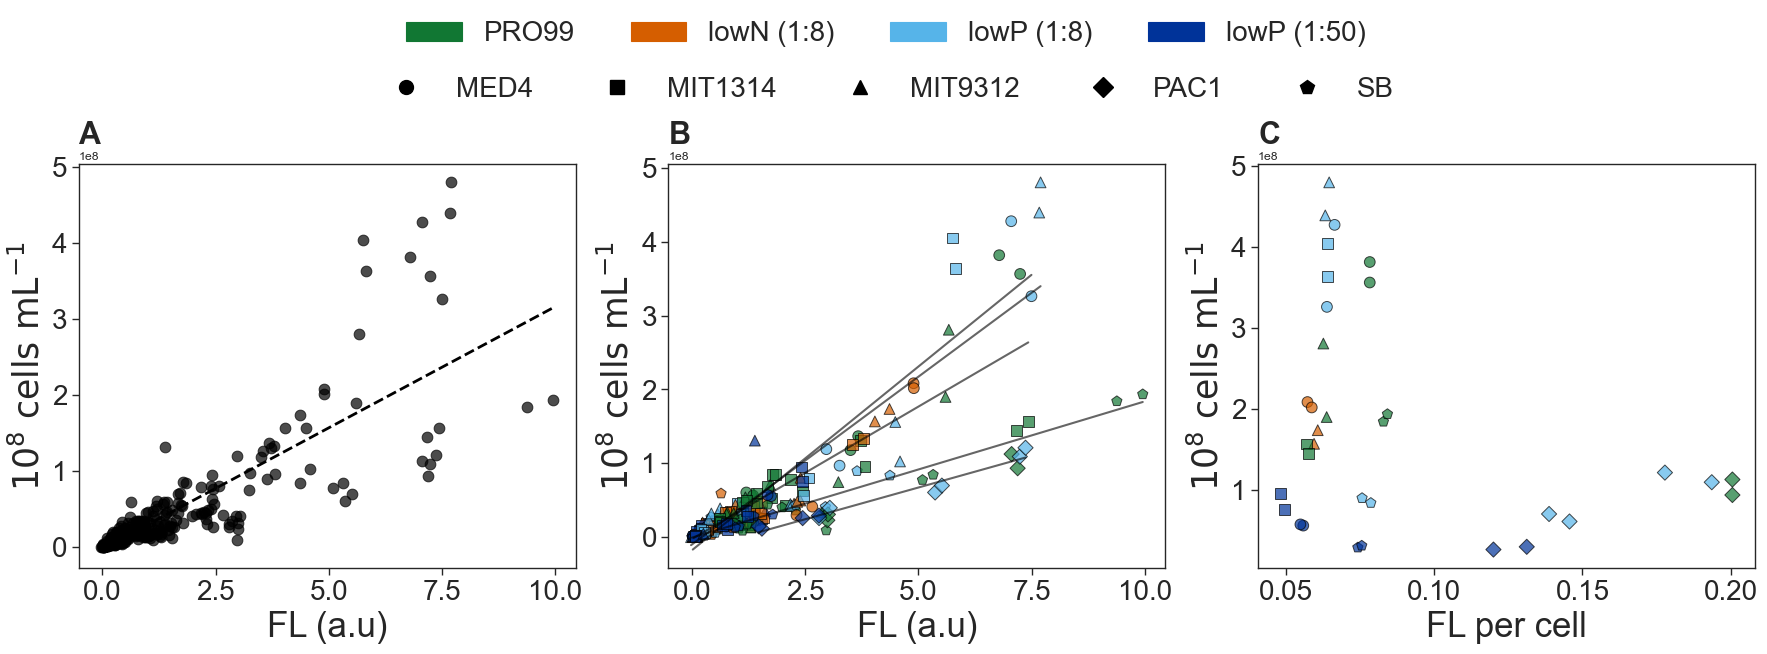

In [24]:
media_palette = {
    'PRO99': '#117733',
    'lowN (1:8)': '#D55E00',
    'lowP (1:8)': '#56B4E9',
    'lowP (1:50)': '#003399'
}

unique_strains = sorted(fl_cellcount['Strain'].unique())
strain_styles = ['o', 's', '^', 'D', 'p', '*', 'X', 'h', 'H', 'd'] 
strain_marker_palette = {
    strain: strain_styles[i % len(strain_styles)] for i, strain in enumerate(unique_strains)
}

plt.rcParams['font.size'] = 16 
label_font = {'fontsize': 25} 


fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False) 


ax = axes[0]

X = fl_cellcount['FL']
Y = fl_cellcount['Cell_count']
X_with_const = sm.add_constant(X)
global_model = sm.OLS(Y, X_with_const).fit()

sns.regplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    scatter=False, 
    ci=None, 
    line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 2}
)

sns.scatterplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    color='black',
    marker='o',
    alpha=0.7,
    s=60,
    edgecolor="black",
    linewidth=0.7,
    legend=False,
)

ax.set_xlabel('FL (a.u)', **label_font)
ax.set_ylabel(r'$10^8 \text{ cells mL}^{-1}$', **label_font) 
ax.tick_params(axis='both', labelsize=20)
ax.set_title('A', fontsize=22, fontweight='bold', loc='left') 
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)


ax = axes[1]

sns.scatterplot(
    data=fl_cellcount,
    x='FL',
    y='Cell_count',
    ax=ax,
    hue='Media',
    style='Strain',
    palette=media_palette,
    markers=strain_marker_palette, 
    alpha=0.7,
    s=60,
    edgecolor="black",
    linewidth=0.7,
    legend=False 
)

for strain, strain_data in fl_cellcount.groupby('Strain'):
    if len(strain_data) > 5:
        sns.regplot(
            data=strain_data,
            x='FL',
            y='Cell_count',
            ax=ax,
            scatter=False,
            ci=None,
            line_kws={'linestyle': '-', 'linewidth': 1.5, 'color': 'black', 'alpha': 0.6},
            scatter_kws={'alpha': 0.15} 
        )

ax.set_xlabel('FL (a.u)', **label_font)
ax.set_ylabel(r'$10^8 \text{ cells mL}^{-1}$', **label_font) # Added y-axis label to Panel B
ax.tick_params(axis='both', labelsize=20)
ax.set_title('B', fontsize=22, fontweight='bold', loc='left') 
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)


ax = axes[2]

df_subset = fl_cellcount[
    (fl_cellcount['experiment'].str.lower() == 'spiking') & 
    (fl_cellcount['phase'].str.lower() == 'peak')
]

sns.scatterplot(
    data=df_subset,
    x="FL per cell_average",
    y="Cell_count",
    ax=ax,
    hue='Media',
    style='Strain',
    palette=media_palette,
    markers=strain_marker_palette,
    alpha=0.7,
    s=60,
    edgecolor="black",
    linewidth=0.7,
    legend=False
)

ax.set_xlabel('FL per cell', **label_font)
ax.set_ylabel(r'$10^8 \text{ cells mL}^{-1}$', **label_font) # Added y-axis label to Panel C
ax.tick_params(axis='both', labelsize=20)
ax.set_title('C', fontsize=22, fontweight='bold', loc='left')
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)


media_handles = []
for media_name, color_code in media_palette.items():
    patch = mpatches.Patch(color=color_code, label=media_name)
    media_handles.append(patch)

strain_handles = []
sorted_strains = sorted(fl_cellcount['Strain'].unique())
for strain_name in sorted_strains:
    marker_style = strain_marker_palette[strain_name]
    line = mlines.Line2D([], [], color='black', marker=marker_style, linestyle='None',
                         markersize=10, label=strain_name)
    strain_handles.append(line)

plt.tight_layout()
fig.subplots_adjust(top=0.72) 

fig.legend(handles=media_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.96), 
           ncol=len(media_handles),    
           frameon=False, 
           fontsize=20, 
           bbox_transform=fig.transFigure)

fig.legend(handles=strain_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.88), 
           ncol=len(strain_handles),   
           frameon=False, 
           fontsize=20, 
           bbox_transform=fig.transFigure)

plt.show()

In [9]:
options = fl_cellcount['phase'].unique()
print(options)

['T0' 'peak' 'growth' 'early decline' 'decline']


In [10]:
fl_cellcount.head()

,experiment,Replicate #,Plate #,Strain,Media,Clade,Sensitivity,phase,Date,Day,FL,Dilution,Cell_count,FL per cell_average
0,followup,2,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.088,1,1175200,0.044457
1,followup,3,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.103,1,1508000,0.044262
2,followup,2,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.113,1,1383400,0.038839
3,followup,3,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.064,1,1046500,0.041491
4,followup,2,1_27.4.26,MIT9312,lowP (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.0,0.073,1,1349900,0.039009


In [11]:

df_followup = fl_cellcount[fl_cellcount['experiment'] == 'followup'].copy()


df_averaged = df_followup.groupby(['Strain', 'Media', 'Day'], as_index=False)[[
    'FL', 'Cell_count', 'FL per cell_average'
]].mean()


summary_data = []


grouped = df_averaged.groupby(['Strain', 'Media'])

for (strain, media), group in grouped:

    max_fl_idx = group['FL'].idxmax()
    peak_row = group.loc[max_fl_idx]
    
    mean_max_fl = peak_row['FL']
    mean_cell_count_at_max_fl = peak_row['Cell_count']
    mean_fl_per_cell_at_max_fl = peak_row['FL per cell_average']
    day_at_max_fl = peak_row['Day']
    

    max_day_idx = group['Day'].idxmax()
    last_row = group.loc[max_day_idx]
    
    mean_last_fl = last_row['FL']
    mean_last_cell_count = last_row['Cell_count']
    mean_last_fl_per_cell = last_row['FL per cell_average']
    last_day_val = last_row['Day']
    

    fl_fold_decline = mean_max_fl / mean_last_fl if mean_last_fl != 0 else float('inf')
    cell_fold_decline = mean_cell_count_at_max_fl / mean_last_cell_count if mean_last_cell_count != 0 else float('inf')
    fl_per_cell_fold_decline = mean_fl_per_cell_at_max_fl / mean_last_fl_per_cell if mean_last_fl_per_cell != 0 else float('inf')
    

    summary_data.append({
        'Strain': strain,
        'Media': media,
        'Peak_Day': day_at_max_fl,
        'Mean_Max_FL': mean_max_fl,
        'Mean_Cell_Count_at_Max_FL': mean_cell_count_at_max_fl,
        'Mean_FL_per_cell_at_Max_FL': mean_fl_per_cell_at_max_fl,
        'Last_Day': last_day_val,
        'Mean_Last_FL': mean_last_fl,
        'Mean_Last_Cell_Count': mean_last_cell_count,
        'Mean_Last_FL_per_cell': mean_last_fl_per_cell,
        'FL_Fold_Decline': round(fl_fold_decline, 2),
        'Cell_Fold_Decline': round(cell_fold_decline, 2),
        'FL_per_cell_Fold_Decline': round(fl_per_cell_fold_decline, 2)
    })


df_summary = pd.DataFrame(summary_data)


print(df_summary[['Strain', 'Media', 'FL_Fold_Decline', 'Cell_Fold_Decline', 'FL_per_cell_Fold_Decline']])

     Strain        Media  FL_Fold_Decline  Cell_Fold_Decline  \
0      MED4        PRO99             2.11               2.66   
1      MED4   lowN (1:8)             1.00               1.00   
2      MED4  lowP (1:50)             1.85               1.51   
3      MED4   lowP (1:8)             1.00               1.00   
4   MIT1314        PRO99             3.59               2.71   
5   MIT1314   lowN (1:8)             8.30               4.81   
6   MIT1314  lowP (1:50)            19.94              12.80   
7   MIT1314   lowP (1:8)             3.85               2.80   
8   MIT9312        PRO99             1.82               1.78   
9   MIT9312   lowN (1:8)            23.22              11.84   
10  MIT9312  lowP (1:50)            14.36               4.98   
11  MIT9312   lowP (1:8)             1.47               0.84   
12       SB        PRO99             1.00               1.00   
13       SB   lowN (1:8)             1.39               0.34   
14       SB  lowP (1:50)             4.5

In [12]:
df_summary

,Strain,Media,Peak_Day,Mean_Max_FL,Mean_Cell_Count_at_Max_FL,Mean_FL_per_cell_at_Max_FL,Last_Day,Mean_Last_FL,Mean_Last_Cell_Count,Mean_Last_FL_per_cell,FL_Fold_Decline,Cell_Fold_Decline,FL_per_cell_Fold_Decline
0,MED4,PRO99,18.947917,1.217333,5.265333e+07,0.033959,28.890972,0.577500,1.978000e+07,0.031322,2.11,2.66,1.08
1,MED4,lowN (1:8),18.947917,0.741333,2.143333e+07,0.038536,18.947917,0.741333,2.143333e+07,0.038536,1.00,1.00,1.00
2,MED4,lowP (1:50),18.947917,0.857333,2.527000e+07,0.041257,23.849306,0.464000,1.674333e+07,0.031890,1.85,1.51,1.29
3,MED4,lowP (1:8),28.890972,0.501000,2.046000e+07,0.032850,28.890972,0.501000,2.046000e+07,0.032850,1.00,1.00,1.00
4,MIT1314,PRO99,21.901389,2.218333,6.143000e+07,0.039010,37.866667,0.617333,2.268333e+07,0.031740,3.59,2.71,1.23
5,MIT1314,lowN (1:8),21.901389,1.454667,2.385333e+07,0.037412,37.866667,0.175333,4.961800e+06,0.027092,8.30,4.81,1.38
6,MIT1314,lowP (1:50),17.093056,1.356000,2.421000e+07,0.043320,37.866667,0.068000,1.891567e+06,0.026185,19.94,12.80,1.65
7,MIT1314,lowP (1:8),21.901389,0.919667,2.462333e+07,0.031642,37.866667,0.238667,8.780000e+06,0.029663,3.85,2.80,1.07
8,MIT9312,PRO99,18.947917,1.495667,5.784333e+07,0.039906,37.866667,0.820000,3.247333e+07,0.001226,1.82,1.78,32.56
9,MIT9312,lowN (1:8),17.093056,2.321500,4.752000e+07,0.042674,37.866667,0.100000,4.014400e+06,0.008993,23.22,11.84,4.75


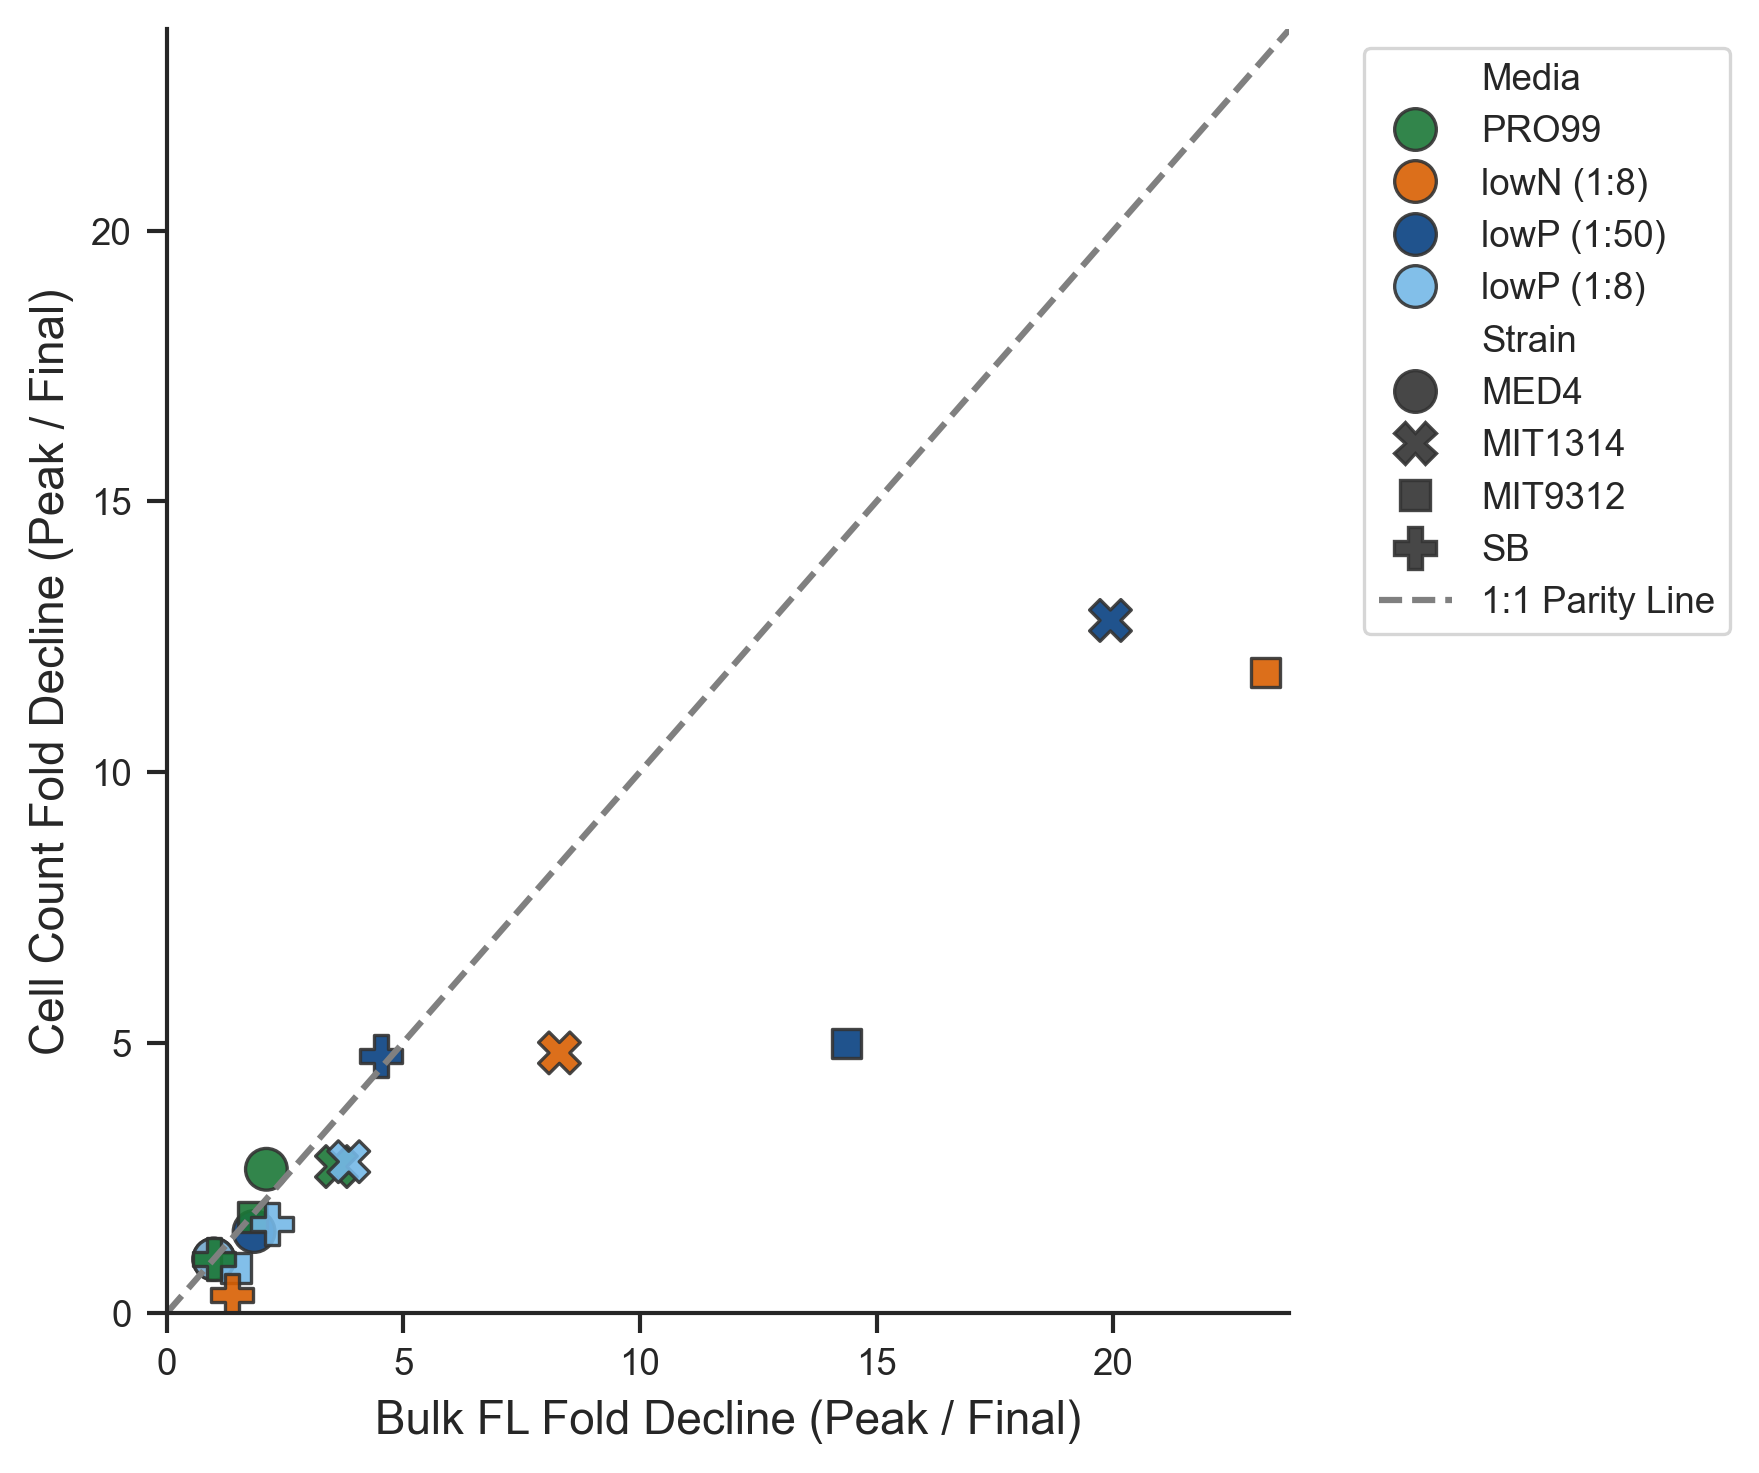

In [13]:
sns.set_theme(style="ticks", context="paper")
plt.figure(figsize=(6, 5), dpi=300)


media_palette = {
    'PRO99': '#1b7837', 'lowN (1:8)': '#d95f02',
    'lowP (1:8)': '#75b8e7', 'lowP (1:50)': '#084081'
}

# 1. Plot the correlation scatter
sns.scatterplot(
    data=df_summary,
    x='FL_Fold_Decline',
    y='Cell_Fold_Decline',
    hue='Media',
    style='Strain',
    palette=media_palette,
    s=100,
    alpha=0.9,
    edgecolor='0.2'
)


max_val = max(df_summary['FL_Fold_Decline'].max(), df_summary['Cell_Fold_Decline'].max())
plt.plot([0, max_val + 1], [0, max_val + 1], color='gray', linestyle='--', linewidth=1.5, label='1:1 Parity Line')


plt.xlabel('Bulk FL Fold Decline (Peak / Final)', fontsize=11)
plt.ylabel('Cell Count Fold Decline (Peak / Final)', fontsize=11)

plt.xlim(0, max_val + 0.5)
plt.ylim(0, max_val + 0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

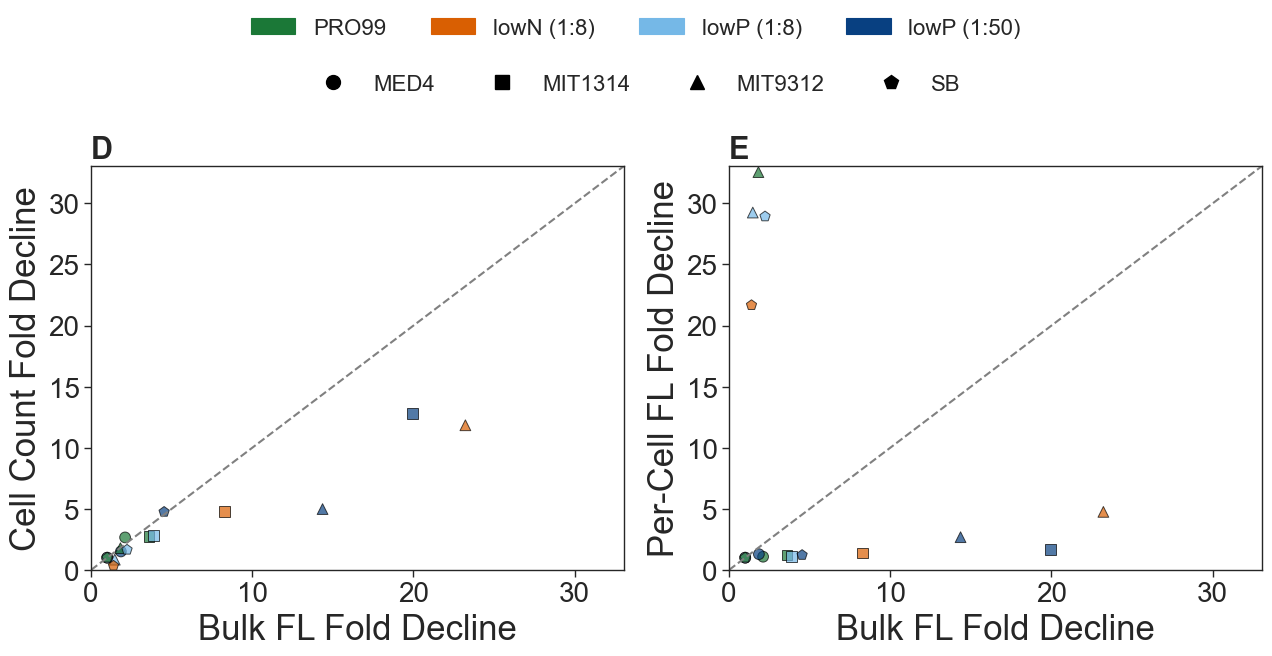

In [14]:
media_palette = {
    'PRO99': '#1b7837', 
    'lowN (1:8)': '#d95f02',
    'lowP (1:8)': '#75b8e7', 
    'lowP (1:50)': '#084081'
}

unique_strains = sorted(df_summary['Strain'].unique())
strain_styles = ['o', 's', '^', 'D', 'p', '*', 'X', 'h', 'H', 'd'] 
strain_marker_palette = {
    strain: strain_styles[i % len(strain_styles)] for i, strain in enumerate(unique_strains)
}

strain_marker_palette['SB'] = 'p'

plt.rcParams['font.size'] = 16 
label_font = {'fontsize': 25} 

# Determine a shared maximum value for consistent axis scaling across both panels
max_val = max(
    df_summary['FL_Fold_Decline'].max(), 
    df_summary['Cell_Fold_Decline'].max(),
    df_summary['FL_per_cell_Fold_Decline'].max()
)
axis_limit = max_val + 0.5

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 7))

# PANEL D (Left)
ax1 = axes[0]
sns.scatterplot(
    data=df_summary,
    x='FL_Fold_Decline',
    y='Cell_Fold_Decline',
    hue='Media',
    style='Strain',
    palette=media_palette,
    markers=strain_marker_palette,
    s=60,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.7,
    ax=ax1,
    legend=False 
)

ax1.plot([0, axis_limit], [0, axis_limit], color='gray', linestyle='--', linewidth=1.5)

# Panel Styling
ax1.set_title('D', fontsize=22, fontweight='bold', loc='left')
ax1.set_xlabel('Bulk FL Fold Decline', **label_font)
ax1.set_ylabel('Cell Count Fold Decline', **label_font)
ax1.set_xlim(0, axis_limit)
ax1.set_ylim(0, axis_limit)
ax1.tick_params(axis='both', labelsize=20)
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)


# PANEL E (Right)
ax2 = axes[1]
sns.scatterplot(
    data=df_summary,
    x='FL_Fold_Decline',
    y='FL_per_cell_Fold_Decline',
    hue='Media',
    style='Strain',
    palette=media_palette,
    markers=strain_marker_palette,
    s=60,
    alpha=0.7,
    edgecolor='black',
    linewidth=0.7,
    ax=ax2,
    legend=False
)

ax2.plot([0, axis_limit], [0, axis_limit], color='gray', linestyle='--', linewidth=1.5)

# Panel Styling
ax2.set_title('E', fontsize=22, fontweight='bold', loc='left')
ax2.set_xlabel('Bulk FL Fold Decline', **label_font)
ax2.set_ylabel('Per-Cell FL Fold Decline', **label_font)
ax2.set_xlim(0, axis_limit)
ax2.set_ylim(0, axis_limit)
ax2.tick_params(axis='both', labelsize=20)
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)


media_handles = []
for media_name, color_code in media_palette.items():
    patch = mpatches.Patch(color=color_code, label=media_name)
    media_handles.append(patch)

strain_handles = []
for strain_name in unique_strains:
    marker_style = strain_marker_palette[strain_name]
    line = mlines.Line2D([], [], color='black', marker=marker_style, linestyle='None',
                         markersize=10, label=strain_name)
    strain_handles.append(line)

plt.tight_layout()

fig.subplots_adjust(top=0.72) 

fig.legend(handles=media_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.96), 
           ncol=len(media_handles),    
           frameon=False, 
           fontsize=16, 
           bbox_transform=fig.transFigure)

fig.legend(handles=strain_handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.88), 
           ncol=len(strain_handles),   
           frameon=False, 
           fontsize=16, 
           bbox_transform=fig.transFigure)

plt.savefig('Decline_Rates_Parity_Comparison.png', bbox_inches='tight')
plt.show()

In [15]:
fl_cellcount

,experiment,Replicate #,Plate #,Strain,Media,Clade,Sensitivity,phase,Date,Day,FL,Dilution,Cell_count,FL per cell_average
0,followup,2,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.000000,0.088,1,1175200,0.044457
1,followup,3,1_27.4.26,MIT9312,PRO99,HLII,N-sensetive,T0,2026-02-08 13:32:00,0.000000,0.103,1,1508000,0.044262
2,followup,2,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.000000,0.113,1,1383400,0.038839
3,followup,3,1_27.4.26,MIT9312,lowN (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.000000,0.064,1,1046500,0.041491
4,followup,2,1_27.4.26,MIT9312,lowP (1:8),HLII,N-sensetive,T0,2026-02-08 13:32:00,0.000000,0.073,1,1349900,0.039009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,spiking,4,3_7.6,MIT1314,lowP (1:50),HLII,N-sensetive,peak,2026-05-19 00:00:00,14.956944,2.436,100,75450000,0.049554
361,spiking,3,3_7.6,MIT9312,lowP (1:8),HLII,N-sensetive,peak,2026-05-20 14:36:00,15.886806,7.670,100,439340000,0.063232
362,spiking,4,3_7.6,MIT9312,lowP (1:8),HLII,N-sensetive,peak,2026-05-20 14:36:00,15.886806,7.699,100,480200000,0.064547
363,spiking,3,3_7.6,PAC1,lowP (1:8),LLI,Other,peak,2026-05-20 14:36:00,15.886806,7.240,100,109130000,0.193614


In [16]:

phase_mask = fl_cellcount['phase'].isin(['early decline', 'decline'])

filtered_df = fl_cellcount[
    (fl_cellcount['experiment'] == 'followup') & 
    (fl_cellcount['Day'] > 0) & 
    phase_mask
].copy()


filtered_df = filtered_df.sort_values(by=['Media', 'Strain', 'Replicate #', 'Day'])


grouped = filtered_df.groupby(['Media', 'Strain', 'Replicate #'])

fl_increased = filtered_df['FL'] > grouped['FL'].shift(1)
cell_increased = filtered_df['Cell_count'] > grouped['Cell_count'].shift(1)
day_increased = filtered_df['Day'] > grouped['Day'].shift(1)


after_indices = filtered_df[fl_increased & cell_increased & day_increased].index


sorted_indices = filtered_df.index.tolist()
before_indices = [sorted_indices[sorted_indices.index(idx) - 1] for idx in after_indices]


all_matching_indices = after_indices.union(before_indices)
compared_df = filtered_df.loc[all_matching_indices].sort_values(by=['Media', 'Strain', 'Replicate #', 'Day'])

compared_df

,experiment,Replicate #,Plate #,Strain,Media,Clade,Sensitivity,phase,Date,Day,FL,Dilution,Cell_count,FL per cell_average
83,followup,2,3_28.4.26,MIT1314,PRO99,HLII,N-sensetive,early decline,2026-02-27 12:17:00,18.947917,1.671,100,68740000,0.038553
114,followup,2,4_28.4.26,MIT1314,PRO99,HLII,N-sensetive,early decline,2026-03-02 11:10:00,21.901389,2.168,100,78550000,0.037055
84,followup,3,3_28.4.26,MIT1314,PRO99,HLII,N-sensetive,early decline,2026-02-27 12:17:00,18.947917,1.752,100,53040000,0.039822
115,followup,3,4_28.4.26,MIT1314,PRO99,HLII,N-sensetive,early decline,2026-03-02 11:10:00,21.901389,2.431,100,62600000,0.038726
204,followup,1,6_29.4.26,SB,PRO99,HLII,Other,decline,2026-03-12 08:07:00,31.774306,0.942,100,15140000,0.046682
248,followup,1,7.1_3.5.26,SB,PRO99,HLII,Other,decline,2026-03-18 10:20:00,37.866667,1.320,100,18690000,0.002360
208,followup,2,6_29.4.26,SB,lowN (1:8),HLII,Other,early decline,2026-03-12 08:07:00,31.774306,0.562,100,11300000,0.042608
252,followup,2,7.1_3.5.26,SB,lowN (1:8),HLII,Other,decline,2026-03-18 10:20:00,37.866667,0.639,100,59140000,0.001754
140,followup,2,8_11.5.26,MIT9312,lowP (1:8),HLII,N-sensetive,early decline,2026-03-04 09:55:00,23.849306,-0.024,1,16800,0.039619
158,followup,2,8_11.5.26,MIT9312,lowP (1:8),HLII,N-sensetive,decline,2026-03-06 11:05:00,25.897917,0.020,1,51100,0.035723


In [17]:

phase_mask = fl_cellcount['phase'].isin(['early decline', 'decline'])

filtered_df = fl_cellcount[
    (fl_cellcount['experiment'] == 'followup') & 
    (fl_cellcount['Day'] > 0) & 
    phase_mask
].copy()


filtered_df = filtered_df.sort_values(by=['Media', 'Strain', 'Replicate #', 'Day'])


grouped = filtered_df.groupby(['Media', 'Strain', 'Replicate #'])


fl_increased = filtered_df['FL'] > grouped['FL'].shift(1)
fl_per_cell_increased = filtered_df['FL per cell_average'] > grouped['FL per cell_average'].shift(1)
day_increased = filtered_df['Day'] > grouped['Day'].shift(1)

after_indices = filtered_df[fl_increased & fl_per_cell_increased & day_increased].index


sorted_indices = filtered_df.index.tolist()
before_indices = [sorted_indices[sorted_indices.index(idx) - 1] for idx in after_indices]


all_matching_indices = after_indices.union(before_indices)
compared_df_percell = filtered_df.loc[all_matching_indices].sort_values(by=['Media', 'Strain', 'Replicate #', 'Day'])

compared_df_percell

,experiment,Replicate #,Plate #,Strain,Media,Clade,Sensitivity,phase,Date,Day,FL,Dilution,Cell_count,FL per cell_average
168,followup,3,5_29.4.26,SB,lowN (1:8),HLII,Other,early decline,2026-03-06 11:05:00,25.897917,0.412,100,11980000,0.041249
200,followup,3,6_29.4.26,SB,lowN (1:8),HLII,Other,early decline,2026-03-09 10:55:00,28.890972,0.432,100,3100000,0.059554
172,followup,1,8_11.5.26,SB,lowP (1:50),HLII,Other,decline,2026-03-06 11:05:00,25.897917,-0.005,1,103400,0.053976
213,followup,1,8_11.5.26,SB,lowP (1:50),HLII,Other,decline,2026-03-12 08:07:00,31.774306,0.005,1,41000,0.061462
174,followup,3,8_11.5.26,SB,lowP (1:50),HLII,Other,decline,2026-03-06 11:05:00,25.897917,0.014,1,3045400,0.038440
259,followup,3,7.1_3.5.26,SB,lowP (1:50),HLII,Other,decline,2026-03-18 10:20:00,37.866667,0.029,1,9500,0.045978
202,followup,2,6_29.4.26,SB,lowP (1:8),HLII,Other,early decline,2026-03-09 10:55:00,28.890972,0.419,100,27030000,0.045024
211,followup,2,6_29.4.26,SB,lowP (1:8),HLII,Other,decline,2026-03-12 08:07:00,31.774306,0.509,100,5880000,0.056579


In [18]:
followup=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\followupexp.xlsx')
followup=followup.drop(followup.index[:2])

In [19]:
followup

,Date,Day,F1,F2,F3,F4,F5,F6,F7,F8,...,F63,F64,F65,F66,F67,F68,F69,F70,F71,F72
2,2026-02-08 13:32:00,0.000000,0.132,0.088,0.103,0.074,0.113,0.064,0.049,0.073,...,0.108,0.083,0.044,0.054,0.059,0.054,0.049,0.054,0.039,0.059
3,2026-02-09 10:54:00,0.890278,0.053,0.106,0.062,0.072,0.091,0.043,0.091,0.096,...,0.109,0.053,0.072,0.043,0.076,0.034,0.086,0.043,0.076,0.034
4,2026-02-10 12:55:00,1.974306,0.067,0.112,0.064,0.092,0.053,0.09,0.063,0.073,...,0.058,0.063,0.029,0.024,0.024,0.029,0.101,0.072,0.024,0.029
5,2026-02-11 12:55:00,2.974306,0.126,0.131,0.164,0.073,0.077,0.096,0.078,0.091,...,0.1,0.015,0.034,0,0.058,0.038,0.077,0.029,0.039,0.024
6,2026-02-12 14:05:00,4.022917,0.179,0.184,0.143,0.072,0.097,0.106,-0.005,0.091,...,0.154,0.014,0.019,0.01,0.024,0.125,0.074,0.019,0.048,0.072
7,2026-02-15 12:13:00,6.945139,0.551,0.673,0.481,0.154,0.197,0.188,0.101,0.173,...,0.376,-0.019,0.043,-0.005,0.063,0.204,0.145,0.092,0.111,0.144
8,2026-02-16 11:00:00,7.894444,0.672,0.955,0.718,0.235,0.341,0.353,0.038,0.165,...,0.553,0.014,0.019,0.02,0.072,0.237,0.261,0.132,0.181,0.209
9,2026-02-17 16:35:00,9.127083,0.846,1.228,0.913,0.471,0.47,0.53,0.122,0.322,...,0.828,0.024,0.087,0.029,0.058,0.315,0.39,0.275,0.304,0.296
10,2026-02-18 15:07:00,10.065972,1.176,1.658,1.136,0.576,0.645,0.732,0.126,0.395,...,1.233,0.014,0.034,0.01,0.029,0.344,0.36,0.365,0.357,0.387
11,2026-02-19 12:03:00,10.938194,1.044,2.09,1.405,0.72,0.802,0.767,0.087,0.519,...,1.725,0.034,0.154,0.005,0.086,0.476,0.548,0.492,0.269,0.377


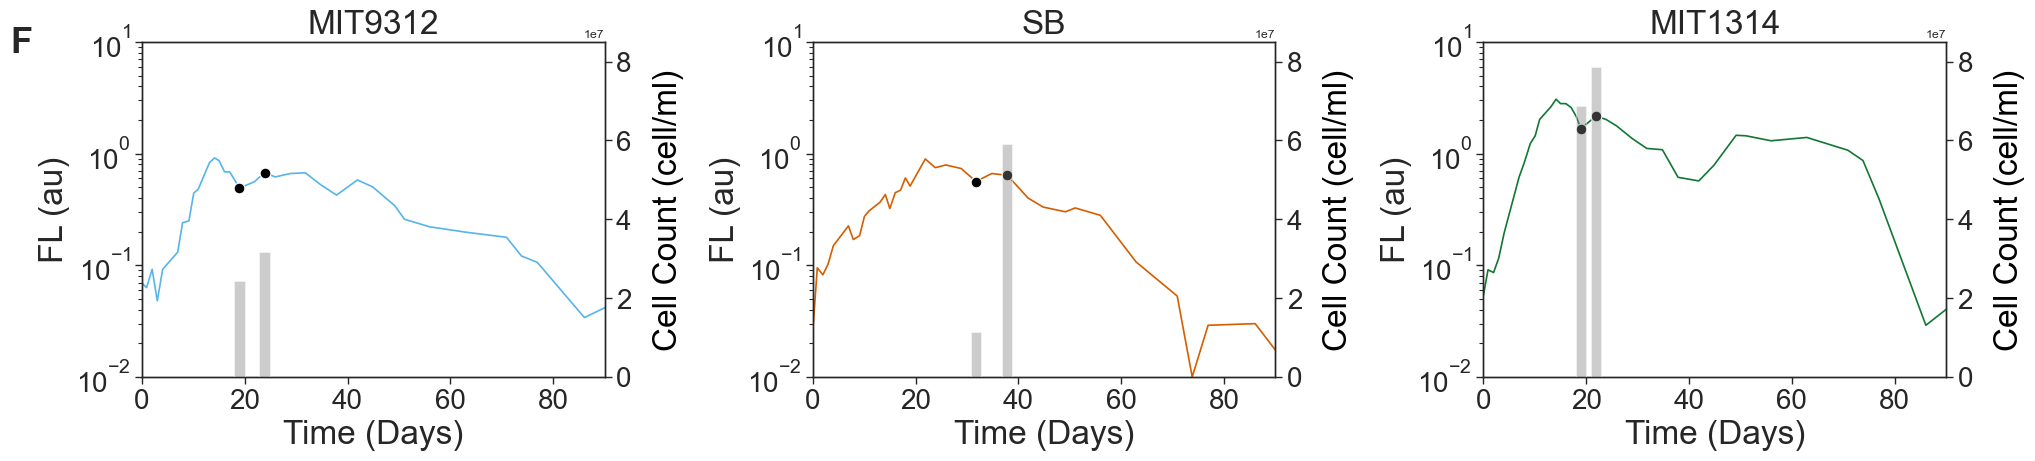

In [20]:
fig = plt.figure(figsize=(22, 5))
plt.subplots_adjust(left=0.08, bottom=0.15, right=0.90, top=0.82, wspace=0.45, hspace=0.4)

GLOBAL_CELL_MAX = 8.5e7


fig.text(0.02, 0.85, 'F', fontsize=26, fontweight='bold', va='top', ha='left')

def plot_strain_data(subplot_idx, strain_name, media_name, repl, column_data, plot_color, label_name, filter_df):
    ax1 = plt.subplot(1, 3, subplot_idx)
    
    ax1.set_yscale("log")
    ax1.set_xlim(0, 90)
    ax1.set_ylim(10**-2, 10**1)
    
    ax1.tick_params(axis='both', which='major', labelsize=20)
    
    # Plot growth curve
    ax1.plot(followup['Day'], followup[column_data], color=plot_color, label=label_name)
    ax1.set_title(strain_name, fontsize=24)
    ax1.set_ylabel('FL (au)', fontsize=24)
    ax1.set_xlabel('Time (Days)', fontsize=24)

    ax2 = ax1.twinx()
    
    # Filter data
    sample = filter_df[
        (filter_df['Strain'] == strain_name) & 
        (filter_df['Media'] == media_name) & 
        (filter_df['Replicate #'] == repl)
    ]
    
    if not sample.empty:

        ax1.scatter(sample['Day'], sample['FL'], color='black', s=60, zorder=10, marker='o', edgecolors='white')
        ax2.bar(sample['Day'], sample['Cell_count'], width=2.0, color='gray', alpha=0.4, zorder=5)
    else:
        print(f"DEBUG: No data found for {strain_name}, {media_name}, Replicate {repl}")
    

    ax2.set_ylim(0, GLOBAL_CELL_MAX)
    
    ax2.set_ylabel('Cell Count (cell/ml)', fontsize=24, color='black', labelpad=15)
    ax2.tick_params(axis='y', labelsize=20)

plot_strain_data(1, 'MIT9312', 'lowP (1:8)', 3, 'F9', '#56B4E9', 'lowP (1:8)', compared_df)
plot_strain_data(2, 'SB', 'lowN (1:8)', 2, 'F29', '#D55E00', 'lowN (1:8)', compared_df)
plot_strain_data(3, 'MIT1314', 'PRO99', 2, 'F50', '#117733', 'PRO99', compared_df)


plt.savefig('graph_paper_sup3.png', dpi=300, bbox_inches='tight')
plt.show()